# Dynamic Pricing Customer Churn — Dunnhumby + XGBoost


## 1. Download the data

In [1]:
!pip install kagglehub

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

from xgboost import XGBClassifier

import kagglehub

path = kagglehub.dataset_download("frtgnn/dunnhumby-the-complete-journey")

print("Path to dataset files:", path)

DATA_DIR = Path(path)
RANDOM_STATE = 42

100%|██████████| 124M/124M [00:01<00:00, 82.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/frtgnn/dunnhumby-the-complete-journey/versions/1


## 2. Load and standardize files


In [2]:
def clean_cols(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )
    return df

def read_csv_flexible(name):
    path = DATA_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Missing {name}. Put it in {DATA_DIR.resolve()} or update DATA_DIR.")
    return clean_cols(pd.read_csv(path))

transactions = read_csv_flexible("transaction_data.csv")
products = read_csv_flexible("product.csv")
demo = read_csv_flexible("hh_demographic.csv")

print(transactions.shape, products.shape, demo.shape)
transactions.head()


(2595732, 12) (92353, 7) (801, 8)


,household_key,basket_id,day,product_id,quantity,sales_value,store_id,retail_disc,trans_time,week_no,coupon_disc,coupon_match_disc
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


## 3. Basic cleaning

This removes impossible transaction rows, creates unit-price features, and joins product metadata.


In [3]:
required = ["household_key", "basket_id", "product_id", "sales_value", "quantity", "week_no", "day"]
missing = [c for c in required if c not in transactions.columns]
if missing:
    raise ValueError(f"Missing required transaction columns: {missing}")

tx = transactions.copy()
tx = tx.drop_duplicates()
tx = tx[(tx["quantity"] > 0) & (tx["sales_value"] >= 0)]

for c in ["retail_disc", "coupon_disc", "coupon_match_disc"]:
    if c not in tx.columns:
        tx[c] = 0
    tx[c] = tx[c].fillna(0)

tx["unit_price_paid"] = tx["sales_value"] / tx["quantity"].replace(0, np.nan)
tx["total_discount"] = tx[["retail_disc", "coupon_disc", "coupon_match_disc"]].sum(axis=1).abs()
tx["discount_rate"] = tx["total_discount"] / (tx["sales_value"] + tx["total_discount"] + 1e-6)
tx["used_discount"] = (tx["total_discount"] > 0).astype(int)

prod_cols = [c for c in ["product_id", "department", "commodity_desc", "sub_commodity_desc", "brand"] if c in products.columns]
tx = tx.merge(products[prod_cols].drop_duplicates("product_id"), on="product_id", how="left")

print(tx.shape)
tx.head()


(2581266, 20)


,household_key,basket_id,day,product_id,quantity,sales_value,store_id,retail_disc,trans_time,week_no,coupon_disc,coupon_match_disc,unit_price_paid,total_discount,discount_rate,used_discount,department,commodity_desc,sub_commodity_desc,brand
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0,1.39,0.60,0.301507,1,PRODUCE,POTATOES,POTATOES RUSSET (BULK&BAG),Private
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0,0.82,0.00,0.000000,0,PRODUCE,ONIONS,ONIONS SWEET (BULK&BAG),National
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0,0.99,0.30,0.232558,1,PRODUCE,VEGETABLES - ALL OTHERS,CELERY,Private
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0,1.21,0.00,0.000000,0,PRODUCE,TROPICAL FRUIT,BANANAS,National
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0,1.50,0.39,0.206349,1,PRODUCE,ORGANICS FRUIT & VEGETABLES,ORGANIC CARROTS,Private


## 4. Create customer-week features

Each row is a household at a week. Features use the previous 8 weeks; the label checks whether the customer makes no purchases in the following 8 weeks.


In [4]:
basket = (
    tx.groupby(["household_key", "week_no", "basket_id"], as_index=False)
      .agg(
          basket_spend=("sales_value", "sum"),
          basket_units=("quantity", "sum"),
          basket_discount=("total_discount", "sum"),
          distinct_products=("product_id", "nunique"),
          avg_discount_rate=("discount_rate", "mean")
      )
)

weekly = (
    basket.groupby(["household_key", "week_no"], as_index=False)
          .agg(
              weekly_spend=("basket_spend", "sum"),
              weekly_units=("basket_units", "sum"),
              weekly_baskets=("basket_id", "nunique"),
              weekly_products=("distinct_products", "sum"),
              weekly_discount=("basket_discount", "sum"),
              avg_basket_value=("basket_spend", "mean"),
              avg_discount_rate=("avg_discount_rate", "mean")
          )
)

all_households = weekly["household_key"].unique()
all_weeks = np.arange(weekly["week_no"].min(), weekly["week_no"].max() + 1)
panel = pd.MultiIndex.from_product([all_households, all_weeks], names=["household_key", "week_no"]).to_frame(index=False)
panel = panel.merge(weekly, on=["household_key", "week_no"], how="left")

activity_cols = ["weekly_spend", "weekly_units", "weekly_baskets", "weekly_products", "weekly_discount", "avg_basket_value", "avg_discount_rate"]
panel[activity_cols] = panel[activity_cols].fillna(0)
panel["active_week"] = (panel["weekly_baskets"] > 0).astype(int)

panel = panel.sort_values(["household_key", "week_no"])
g = panel.groupby("household_key", group_keys=False)

lookback = 8
future_window = 8

for col in ["weekly_spend", "weekly_units", "weekly_baskets", "weekly_products", "weekly_discount", "active_week"]:
    panel[f"{col}_last{lookback}"] = (
        g[col].shift(1).rolling(lookback, min_periods=1).sum().reset_index(level=0, drop=True)
    )

panel[f"avg_discount_rate_last{lookback}"] = (
    g["avg_discount_rate"].shift(1).rolling(lookback, min_periods=1).mean().reset_index(level=0, drop=True)
)

panel[f"avg_basket_value_last{lookback}"] = (
    g["avg_basket_value"].shift(1).rolling(lookback, min_periods=1).mean().reset_index(level=0, drop=True)
)

def weeks_since_last_purchase(s):
    last = -999
    out = []
    for i, val in enumerate(s.values):
        out.append(i - last if last != -999 else 999)
        if val == 1:
            last = i
    return pd.Series(out, index=s.index)

panel["weeks_since_purchase"] = g["active_week"].apply(weeks_since_last_purchase).reset_index(level=0, drop=True)

panel["future_active_weeks"] = (
    g["active_week"].shift(-1).rolling(future_window, min_periods=1).sum().reset_index(level=0, drop=True)
)
panel["observed_churn_next8"] = (panel["future_active_weeks"] == 0).astype(int)

max_week = panel["week_no"].max()
model_base = panel[(panel["week_no"] >= lookback + 1) & (panel["week_no"] <= max_week - future_window)].copy()

print(model_base["observed_churn_next8"].value_counts(normalize=True))
model_base.head()


observed_churn_next8
0    0.866391
1    0.133609
Name: proportion, dtype: float64


,household_key,week_no,weekly_spend,weekly_units,weekly_baskets,weekly_products,weekly_discount,avg_basket_value,avg_discount_rate,active_week,...,weekly_units_last8,weekly_baskets_last8,weekly_products_last8,weekly_discount_last8,active_week_last8,avg_discount_rate_last8,avg_basket_value_last8,weeks_since_purchase,future_active_weeks,observed_churn_next8
8,1,9,0.0,0.0,0.0,0.0,0.00,0.0,0.000000,0,...,34.0,1.0,30.0,17.54,1.0,0.018704,9.8325,1,2.0,0
9,1,10,41.1,14.0,1.0,11.0,8.59,41.1,0.149036,1,...,34.0,1.0,30.0,17.54,1.0,0.018704,9.8325,2,2.0,0
10,1,11,0.0,0.0,0.0,0.0,0.00,0.0,0.000000,0,...,48.0,2.0,41.0,26.13,2.0,0.037333,14.9700,1,2.0,0
11,1,12,0.0,0.0,0.0,0.0,0.00,0.0,0.000000,0,...,48.0,2.0,41.0,26.13,2.0,0.037333,14.9700,2,3.0,0
12,1,13,26.9,13.0,1.0,12.0,6.72,26.9,0.181620,1,...,48.0,2.0,41.0,26.13,2.0,0.037333,14.9700,3,4.0,0


## 5. Add demographic features and simulate dynamic price increases

Because prices are not actually changed in the historical data, we create scenario rows with possible price increases. The target below combines actual future inactivity with a transparent simulated churn rule based on each customer’s discount dependence.

In [5]:
demo_clean = demo.copy()
if "household_key" not in demo_clean.columns:
    raise ValueError("hh_demographic.csv must include household_key")

model_base = model_base.merge(demo_clean, on="household_key", how="left")

price_scenarios = pd.DataFrame({"price_increase_pct": [0.00, 0.05, 0.10, 0.15, 0.20]})
model_df = model_base.merge(price_scenarios, how="cross")

disc_col = f"avg_discount_rate_last{lookback}"
model_df["discount_dependency"] = model_df[disc_col].fillna(0).clip(0, 1)
model_df["price_tolerance"] = 0.18 - 0.12 * model_df["discount_dependency"]
price_excess = (model_df["price_increase_pct"] - model_df["price_tolerance"]).clip(-0.15, 0.15)
churn_prob_from_price = 1 / (1 + np.exp(-20 * price_excess))
np.random.seed(RANDOM_STATE)
model_df["simulated_price_churn"] = np.random.binomial(1, churn_prob_from_price)
model_df["churn"] = (
    (model_df["observed_churn_next8"] == 1) | (model_df["simulated_price_churn"] == 1)
).astype(int)

print(model_df["churn"].value_counts(normalize=True))
model_df.head()


churn
0    0.631487
1    0.368513
Name: proportion, dtype: float64


,household_key,week_no,weekly_spend,weekly_units,weekly_baskets,weekly_products,weekly_discount,avg_basket_value,avg_discount_rate,active_week,...,income_desc,homeowner_desc,hh_comp_desc,household_size_desc,kid_category_desc,price_increase_pct,discount_dependency,price_tolerance,simulated_price_churn,churn
0,1,9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,...,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,0.00,0.018704,0.177756,0,0
1,1,9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,...,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,0.05,0.018704,0.177756,1,1
2,1,9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,...,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,0.10,0.018704,0.177756,0,0
3,1,9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,...,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,0.15,0.018704,0.177756,0,0
4,1,9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,...,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,0.20,0.018704,0.177756,1,1


## 6. Train/test split

This uses a time-based split so later weeks are treated as unseen future behavior.


In [6]:
drop_cols = [
    "household_key","week_no", "observed_churn_next8", "future_active_weeks",
    "simulated_price_churn", "price_tolerance", "churn"
]

feature_cols = [c for c in model_df.columns if c not in drop_cols]
X = model_df[feature_cols]
y = model_df["churn"]

split_week = int(model_df["week_no"].quantile(0.80))
train_idx = model_df["week_no"] <= split_week
test_idx = model_df["week_no"] > split_week

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Numeric:", len(num_cols), "Categorical:", len(cat_cols))


Train: (862500, 26) Test: (212500, 26)
Numeric: 19 Categorical: 7


## 7. Logistic Regression (Baseline)

In [7]:
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / max(pos, 1)

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)


In [8]:
from sklearn.linear_model import LogisticRegression

# class imbalance for churners, balance
log_reg = Pipeline(steps=[
    ("preprocess", preprocess),
     ("model", LogisticRegression(max_iter=1000,class_weight="balanced"))])

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:,1]

In [9]:
feature_names_lr = log_reg.named_steps["preprocess"].get_feature_names_out()
coef_lr = log_reg.named_steps["model"].coef_[0]

coef_df_lr = pd.DataFrame({
    "feature": feature_names_lr,
    "coefficient": coef_lr}).sort_values(by="coefficient", key=abs, ascending=False)

coef_df_lr.head(8)

,feature,coefficient
13,num__active_week_last8,-0.087144
40,cat__homeowner_desc_Homeowner,0.050850
47,cat__hh_comp_desc_2 Adults No Kids,0.050346
52,cat__household_size_desc_2,0.050140
22,cat__age_desc_45-54,0.050114
37,cat__income_desc_50-74K,0.049785
59,cat__kid_category_desc_None/Unknown,0.049402
27,cat__marital_status_code_U,0.048801


In [10]:
print(classification_report(y_test, y_pred_lr))
print(roc_auc_score(y_test, y_prob_lr))
confusion_matrix(y_test, y_pred_lr)

              precision    recall  f1-score   support

           0       0.72      0.73      0.73    137382
           1       0.50      0.49      0.49     75118

    accuracy                           0.64    212500
   macro avg       0.61      0.61      0.61    212500
weighted avg       0.64      0.64      0.64    212500

0.6424989529578043


array([[100245,  37137],
       [ 38482,  36636]])

## Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier

# class imbalance for churners, balance
rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(n_estimators=200, max_depth=8, random_state=67, class_weight="balanced"))])

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [12]:
importances = rf.named_steps["model"].feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names_lr,
    "importance": importances}).sort_values(by="importance", ascending=False)

feat_imp.head(15)

,feature,importance
17,num__price_increase_pct,0.318744
16,num__weeks_since_purchase,0.179875
11,num__weekly_products_last8,0.072912
10,num__weekly_baskets_last8,0.063393
13,num__active_week_last8,0.053041
9,num__weekly_units_last8,0.051823
12,num__weekly_discount_last8,0.037255
8,num__weekly_spend_last8,0.035208
14,num__avg_discount_rate_last8,0.032766
18,num__discount_dependency,0.026575


In [13]:
print(classification_report(y_test, y_pred_rf))
print(roc_auc_score(y_test, y_prob_rf))
confusion_matrix(y_test, y_pred_rf)

              precision    recall  f1-score   support

           0       0.87      0.77      0.82    137382
           1       0.65      0.79      0.71     75118

    accuracy                           0.78    212500
   macro avg       0.76      0.78      0.77    212500
weighted avg       0.79      0.78      0.78    212500

0.8521886840078233


array([[105725,  31657],
       [ 15878,  59240]])

## 8. XGBoost model


In [14]:
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / max(pos, 1)

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1
)

model = Pipeline([
    ("preprocess", preprocess),
    ("xgb", xgb)
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "auc": roc_auc_score(y_test, y_prob)
}

pd.Series(metrics).round(4)


,0
accuracy,0.7729
precision,0.6413
recall,0.8111
f1,0.7163
auc,0.8596


In [15]:
print(classification_report(y_test, y_pred, zero_division=0))
print("Confusion matrix:")
confusion_matrix(y_test, y_pred)


              precision    recall  f1-score   support

           0       0.88      0.75      0.81    137382
           1       0.64      0.81      0.72     75118

    accuracy                           0.77    212500
   macro avg       0.76      0.78      0.76    212500
weighted avg       0.80      0.77      0.78    212500

Confusion matrix:


array([[103303,  34079],
       [ 14188,  60930]])

## 9. Price scenario analysis

This estimates how average churn probability changes under different price increases.


In [16]:
scenario_results = []
base_customers = model_base.copy()

for pct in [0.00, 0.05, 0.10, 0.15, 0.20]:
    scenario = base_customers.copy()
    scenario["price_increase_pct"] = pct
    scenario["discount_dependency"] = scenario[f"avg_discount_rate_last{lookback}"].fillna(0).clip(0, 1)
    scenario_X = scenario.reindex(columns=feature_cols, fill_value=0)
    churn_prob = model.predict_proba(scenario_X)[:, 1]
    scenario_results.append({
        "price_increase_pct": pct,
        "avg_predicted_churn_probability": churn_prob.mean(),
        "median_predicted_churn_probability": np.median(churn_prob),
        "estimated_revenue_multiplier": (1 + pct) * (1 - churn_prob.mean())
    })

scenario_results = pd.DataFrame(scenario_results)
scenario_results


,price_increase_pct,avg_predicted_churn_probability,median_predicted_churn_probability,estimated_revenue_multiplier
0,0.00,0.207418,0.078471,0.792582
1,0.05,0.250106,0.128863,0.787388
2,0.10,0.388813,0.292173,0.672306
3,0.15,0.590229,0.528851,0.471237
4,0.20,0.781029,0.753355,0.262765


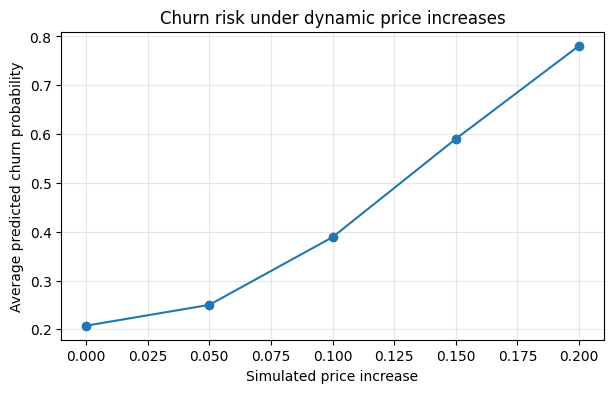

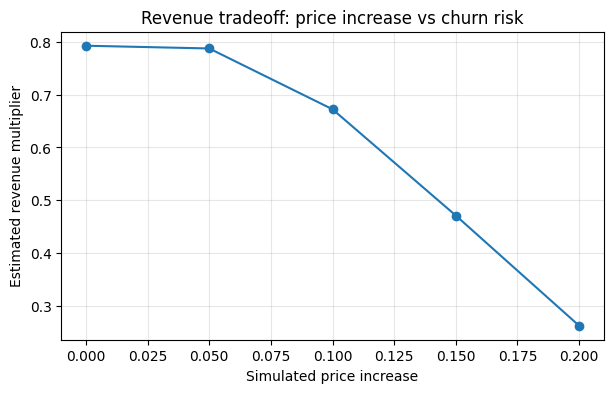

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(scenario_results["price_increase_pct"], scenario_results["avg_predicted_churn_probability"], marker="o")
plt.xlabel("Simulated price increase")
plt.ylabel("Average predicted churn probability")
plt.title("Churn risk under dynamic price increases")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(scenario_results["price_increase_pct"], scenario_results["estimated_revenue_multiplier"], marker="o")
plt.xlabel("Simulated price increase")
plt.ylabel("Estimated revenue multiplier")
plt.title("Revenue tradeoff: price increase vs churn risk")
plt.grid(True, alpha=0.3)
plt.show()


## 10. XGBoost + Isotonic Calibration


Train: 690,000 rows | Calibration: 172,500 rows | Test: 212,500 rows
Churn rate  — train: 0.372 | cal: 0.372 | test: 0.353

Base XGBoost trained.
Isotonic calibration fitted on held-out calibration set.

Optimal threshold (max F1): 0.3693
Default threshold:           0.5000

── Final Comparison Table ──────────────────────────────────────────────
                          F1  Precision  Accuracy   Brier
Model                                                    
Raw XGBoost           0.7162     0.6411    0.7727  0.1469
Calibrated (t=0.50)   0.6956     0.7574    0.8010  0.1396
Calibrated (t=0.369)  0.7167     0.6290    0.7673  0.1396


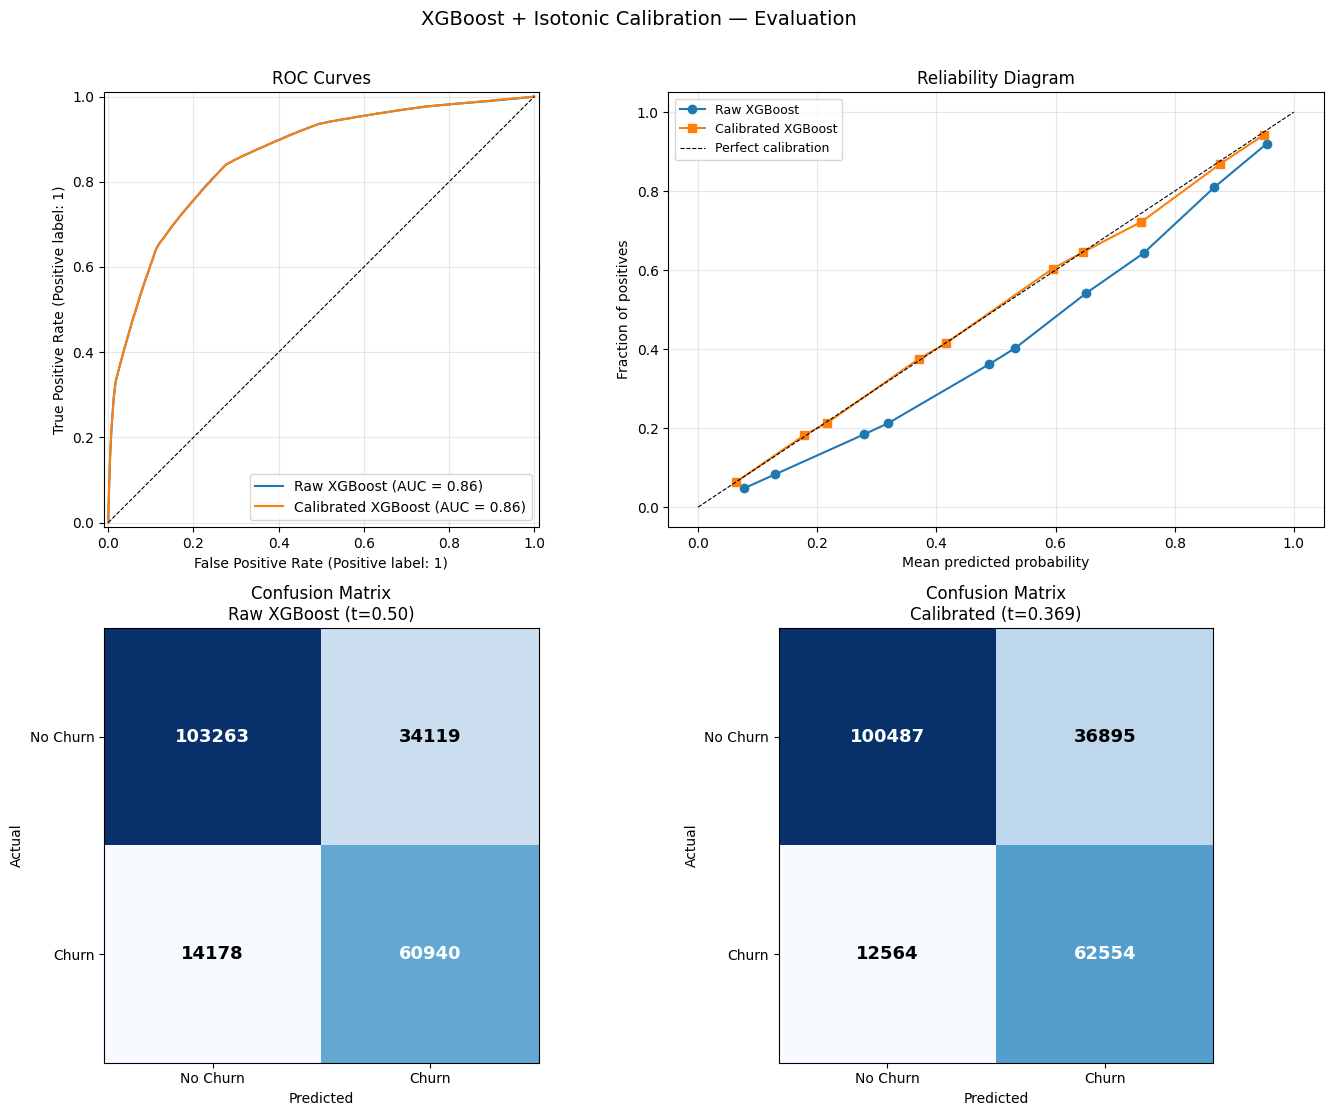

In [18]:
import matplotlib.pyplot as plt

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    brier_score_loss, RocCurveDisplay, precision_recall_curve
)
RANDOM_STATE = 42


# Train / Calibration split

#splitting data between training and calibration
X_tr, X_cal, y_tr, y_cal = train_test_split(
    X_train, y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    # stratify=y_train          # preserve class ratio in both splits
)

print(f"Train: {X_tr.shape[0]:,} rows | "
      f"Calibration: {X_cal.shape[0]:,} rows | "
      f"Test: {X_test.shape[0]:,} rows")
print(f"Churn rate  — train: {y_tr.mean():.3f} | "
      f"cal: {y_cal.mean():.3f} | test: {y_test.mean():.3f}")


# Build and train base XGBoost on X_tr only
pos = y_tr.sum()
neg = len(y_tr) - pos
scale_pos_weight = neg / max(pos, 1)

num_cols = X_tr.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_tr.select_dtypes(exclude=[np.number]).columns.tolist()

preprocess = ColumnTransformer(transformers=[
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), cat_cols)
])

xgb = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.85, colsample_bytree=0.85,
    objective="binary:logistic", eval_metric="logloss",
    random_state=RANDOM_STATE,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1
)

model = Pipeline([("preprocess", preprocess), ("xgb", xgb)])
model.fit(X_tr, y_tr)

y_prob_raw = model.predict_proba(X_test)[:, 1]
y_pred_raw = (y_prob_raw >= 0.5).astype(int)
print("\nBase XGBoost trained.")


# Calibrate on data for calibration set to ensure only unseen data

calibrated_model = CalibratedClassifierCV(
    estimator=model, method="isotonic", cv="prefit"
)
calibrated_model.fit(X_cal, y_cal)

y_prob_cal = calibrated_model.predict_proba(X_test)[:, 1]
print("Isotonic calibration fitted on held-out calibration set.")


# Threshold optimisation
# In imbalanced churn problems, 0.5 is arbitrary. We sweep thresholds and
# pick the one that maximises F1 on the test set probabilities.

# Select threshold on calibration set only
cal_probs = calibrated_model.predict_proba(X_cal)[:, 1]
prec_c, rec_c, thresh_c = precision_recall_curve(y_cal, cal_probs)
f1_c = np.where(
    (prec_c[:-1] + rec_c[:-1]) > 0,
    2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1]),
    0
)
best_threshold = thresh_c[np.argmax(f1_c)]  # never looked at y_test

# Now apply to test, no further tuning
y_pred_cal_tuned = (y_prob_cal >= best_threshold).astype(int)
y_pred_cal_default = (y_prob_cal >= 0.5).astype(int)

print(f"\nOptimal threshold (max F1): {best_threshold:.4f}")
print(f"Default threshold:           0.5000")


# ── 5. Metrics helper ────────────────────────────────────────────────────────
def get_metrics(y_true, y_pred, y_prob, label=""):
    return {
        "Model":     label,
        "F1":        round(f1_score(y_true, y_pred, zero_division=0),         4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0),  4),
        "Accuracy":  round(accuracy_score(y_true, y_pred),                    4),
        "Brier":     round(brier_score_loss(y_true, y_prob),                  4),
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_raw,         y_prob_raw, "Raw XGBoost"),
    get_metrics(y_test, y_pred_cal_default, y_prob_cal, "Calibrated (t=0.50)"),
    get_metrics(y_test, y_pred_cal_tuned,   y_prob_cal,
                f"Calibrated (t={best_threshold:.3f})"),
]).set_index("Model")

print("\n── Final Comparison Table ──────────────────────────────────────────────")
print(results.to_string())


###### Plots ######
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("XGBoost + Isotonic Calibration — Evaluation", fontsize=14, y=1.01)

# ROC curves
ax = axes[0, 0]
RocCurveDisplay.from_predictions(y_test, y_prob_raw,  name="Raw XGBoost",         ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_cal,  name="Calibrated XGBoost",  ax=ax)
ax.plot([0,1],[0,1], "k--", lw=0.8)
ax.set_title("ROC Curves")
ax.grid(True, alpha=0.3)

# Reliability diagram
ax = axes[0, 1]
frac_pos_raw, mean_pred_raw = calibration_curve(y_test, y_prob_raw, n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_prob_cal, n_bins=10)
ax.plot(mean_pred_raw, frac_pos_raw, marker="o", label="Raw XGBoost")
ax.plot(mean_pred_cal, frac_pos_cal, marker="s", label="Calibrated XGBoost")
ax.plot([0,1],[0,1], "k--", lw=0.8, label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Reliability Diagram")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Confusion matrices side by side (raw vs tuned threshold)
for i, (y_pred, title) in enumerate([
    (y_pred_raw,       "Raw XGBoost (t=0.50)"),
    (y_pred_cal_tuned, f"Calibrated (t={best_threshold:.3f})")
]):
    ax = axes[1, i]
    cm = confusion_matrix(y_test, y_pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["No Churn","Churn"])
    ax.set_yticklabels(["No Churn","Churn"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix\n{title}")
    for r in range(2):
        for c in range(2):
            ax.text(c, r, cm[r,c], ha="center", va="center",
                    color="white" if cm[r,c] > cm.max()/2 else "black",
                    fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


# # Feature importance (gain-based)
# ohe_cols  = (model.named_steps["preprocess"]
#                   .named_transformers_["cat"]
#                   .named_steps["onehot"]
#                   .get_feature_names_out(cat_cols).tolist())
# all_feat_names = num_cols + ohe_cols

# booster   = model.named_steps["xgb"].get_booster()
# raw_scores = booster.get_score(importance_type="gain")

# feat_imp = (
#     pd.Series(raw_scores)
#       .rename_axis("feature")
#       .reset_index(name="gain")
#       .assign(feature=lambda d: d["feature"].str.replace(r"^f(\d+)$",
#           lambda m: all_feat_names[int(m.group(1))]
#               if int(m.group(1)) < len(all_feat_names) else m.group(0),
#           regex=True))
#       .sort_values("gain", ascending=False)
#       .head(15)
# )

# fig2, ax2 = plt.subplots(figsize=(8, 5))
# ax2.barh(feat_imp["feature"][::-1], feat_imp["gain"][::-1])
# ax2.set_xlabel("Gain (total information gain from splits on this feature)")
# ax2.set_title("Top 15 Features — XGBoost Gain Importance")
# ax2.grid(True, alpha=0.3, axis="x")
# plt.tight_layout()
# plt.show()

── All-Model Comparison ────────────────────────────────────────────────
                             Accuracy  Precision  Recall      F1     AUC   Brier
Model                                                                           
Logistic Regression            0.6441     0.4966  0.4877  0.4921  0.6425  0.2247
Random Forest                  0.7763     0.6517  0.7886  0.7137  0.8522  0.1585
XGBoost                        0.7673     0.6290  0.8327  0.7167  0.8596  0.1468
XGBoost + Isotonic (t=0.37)    0.7673     0.6290  0.8327  0.7167  0.8596  0.1396


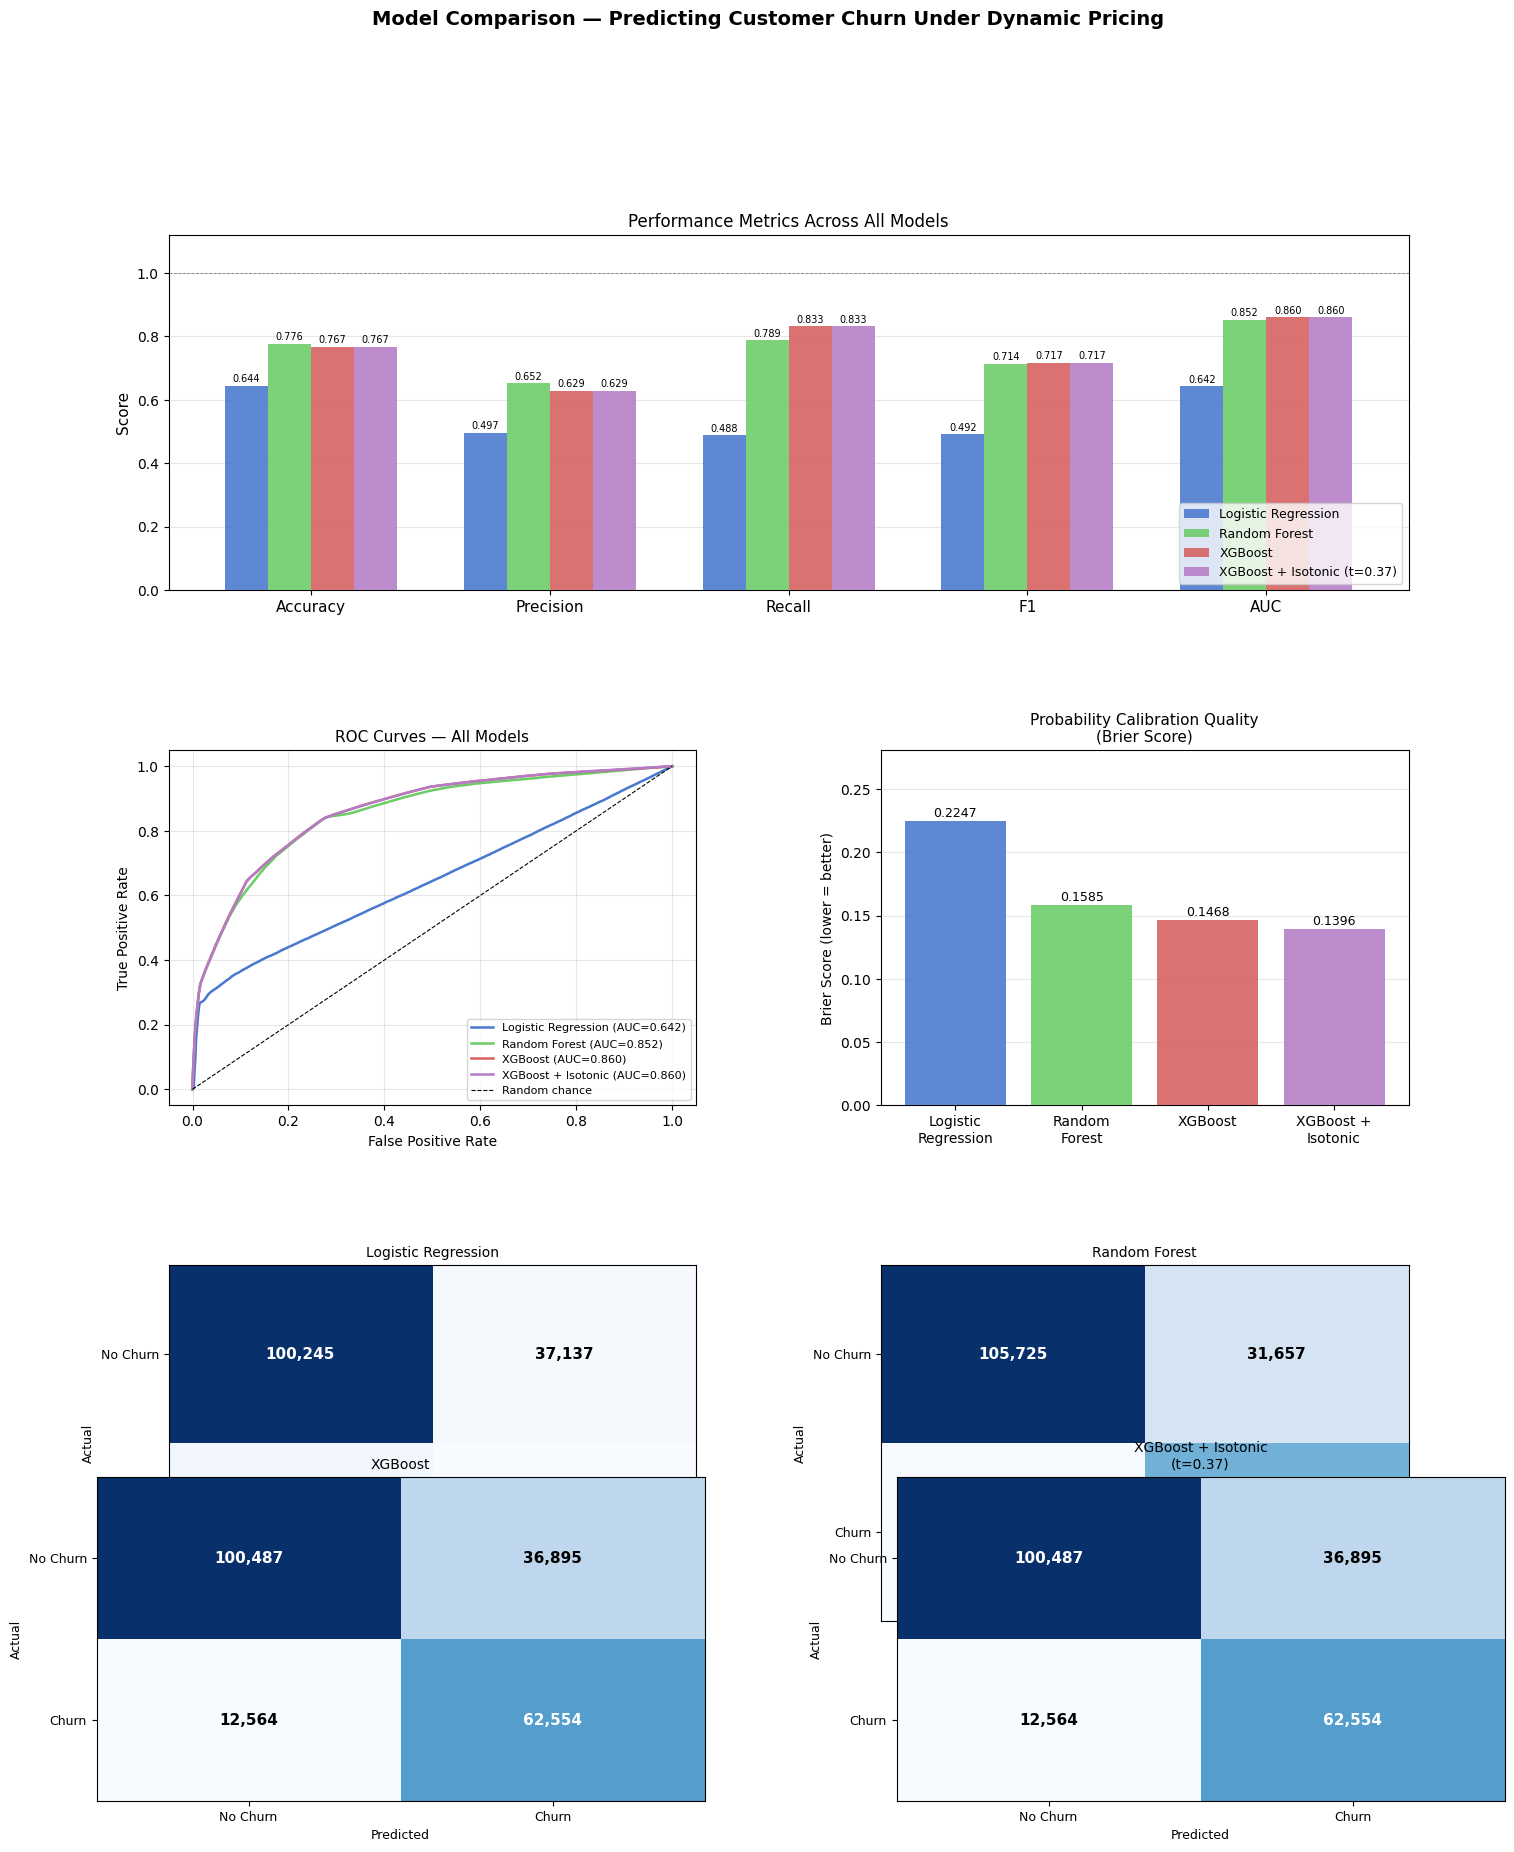

Saved → model_comparison.png

── Table 1: Summary of Model Performance ───────────────────────────────
                             Accuracy  Precision  Recall      F1     AUC   Brier
Model                                                                           
Logistic Regression            0.6441     0.4966  0.4877  0.4921  0.6425  0.2247
Random Forest                  0.7763     0.6517  0.7886  0.7137  0.8522  0.1585
XGBoost                        0.7673     0.6290  0.8327  0.7167  0.8596  0.1468
XGBoost + Isotonic (t=0.37)    0.7673     0.6290  0.8327  0.7167  0.8596  0.1396


In [ ]:
# And predictions:
#   y_pred_lr, y_prob_lr
#   y_pred_rf, y_prob_rf
#   y_pred,    y_prob        (raw XGBoost)
#   y_pred_cal_tuned, y_prob_cal  (calibrated XGBoost)
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, brier_score_loss,
    confusion_matrix, roc_curve
)

# ── 1. Build unified metrics table ───────────────────────────────────────────
def metrics_row(label, y_true, y_pred, y_prob):
    return {
        "Model":     label,
        "Accuracy":  round(accuracy_score(y_true, y_pred),                   4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_true, y_pred, zero_division=0),    4),
        "F1":        round(f1_score(y_true, y_pred, zero_division=0),        4),
        "AUC":       round(roc_auc_score(y_true, y_prob),                    4),
        "Brier":     round(brier_score_loss(y_true, y_prob),                 4),
    }

summary = pd.DataFrame([
    metrics_row("Logistic Regression",        y_test, y_pred_lr,         y_prob_lr),
    metrics_row("Random Forest",              y_test, y_pred_rf,         y_prob_rf),
    metrics_row("XGBoost",                    y_test, y_pred,            y_prob),
    metrics_row(f"XGBoost + Isotonic (t={best_threshold:.2f})",
                                              y_test, y_pred_cal_tuned,  y_prob_cal),
]).set_index("Model")

print("── All-Model Comparison ────────────────────────────────────────────────")
print(summary.to_string())


# ── 2. Figure layout: metrics table + bar chart + ROC curves + confusion matrices
fig = plt.figure(figsize=(16, 18))
fig.suptitle("Model Comparison — Predicting Customer Churn Under Dynamic Pricing",
             fontsize=14, fontweight="bold", y=1.005)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

MODELS  = summary.index.tolist()
COLORS  = ["#4878CF", "#6ACC65", "#D65F5F", "#B47CC7"]
METRICS = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

# ── 2a. Grouped bar chart of core metrics ────────────────────────────────────
ax_bar = fig.add_subplot(gs[0, :])   # full-width top row

x       = np.arange(len(METRICS))
n       = len(MODELS)
width   = 0.18
offsets = np.linspace(-(n-1)/2 * width, (n-1)/2 * width, n)

for i, (model_name, color) in enumerate(zip(MODELS, COLORS)):
    vals = [summary.loc[model_name, m] for m in METRICS]
    bars = ax_bar.bar(x + offsets[i], vals, width,
                      label=model_name, color=color, alpha=0.88, zorder=3)
    for bar, val in zip(bars, vals):
        ax_bar.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"{val:.3f}", ha="center", va="bottom",
                    fontsize=7, color="black")

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(METRICS, fontsize=11)
ax_bar.set_ylim(0, 1.12)
ax_bar.set_ylabel("Score", fontsize=11)
ax_bar.set_title("Performance Metrics Across All Models", fontsize=12)
ax_bar.legend(fontsize=9, loc="lower right")
ax_bar.grid(True, alpha=0.3, axis="y", zorder=0)
ax_bar.axhline(1.0, color="gray", lw=0.6, linestyle="--")


# ── 2b. ROC curves ───────────────────────────────────────────────────────────
ax_roc = fig.add_subplot(gs[1, 0])

for (model_name, y_prob_plot), color in zip(
    [("Logistic Regression",       y_prob_lr),
     ("Random Forest",             y_prob_rf),
     ("XGBoost",                   y_prob),
     (f"XGBoost + Isotonic",       y_prob_cal)],
    COLORS
):
    fpr, tpr, _ = roc_curve(y_test, y_prob_plot)
    auc_val = roc_auc_score(y_test, y_prob_plot)
    ax_roc.plot(fpr, tpr, color=color, lw=1.8,
                label=f"{model_name} (AUC={auc_val:.3f})")

ax_roc.plot([0,1],[0,1], "k--", lw=0.8, label="Random chance")
ax_roc.set_xlabel("False Positive Rate", fontsize=10)
ax_roc.set_ylabel("True Positive Rate", fontsize=10)
ax_roc.set_title("ROC Curves — All Models", fontsize=11)
ax_roc.legend(fontsize=8, loc="lower right")
ax_roc.grid(True, alpha=0.3)


# ── 2c. Brier score bar (lower = better) ────────────────────────────────────
ax_brier = fig.add_subplot(gs[1, 1])

brier_vals  = [summary.loc[m, "Brier"] for m in MODELS]
short_names = ["Logistic\nRegression", "Random\nForest",
               "XGBoost", "XGBoost +\nIsotonic"]

bars = ax_brier.bar(short_names, brier_vals, color=COLORS, alpha=0.88, zorder=3)
for bar, val in zip(bars, brier_vals):
    ax_brier.text(bar.get_x() + bar.get_width() / 2,
                  bar.get_height() + 0.001,
                  f"{val:.4f}", ha="center", va="bottom", fontsize=9)

ax_brier.set_ylabel("Brier Score (lower = better)", fontsize=10)
ax_brier.set_title("Probability Calibration Quality\n(Brier Score)", fontsize=11)
ax_brier.grid(True, alpha=0.3, axis="y", zorder=0)
ax_brier.set_ylim(0, max(brier_vals) * 1.25)


# ── 2d. Confusion matrices for all four models ───────────────────────────────
cm_models = [
    ("Logistic Regression",  y_pred_lr),
    ("Random Forest",        y_pred_rf),
    ("XGBoost",              y_pred),
    (f"XGBoost + Isotonic\n(t={best_threshold:.2f})", y_pred_cal_tuned),
]

for idx, (title, y_pred_plot) in enumerate(cm_models):
    row = 2
    col = idx % 2
    if idx == 0:
        ax_cm = fig.add_subplot(gs[row, 0])
    elif idx == 1:
        ax_cm = fig.add_subplot(gs[row, 1])
    elif idx == 2:
        # need an extra row — add subplot manually
        ax_cm = fig.add_axes([0.08 + (idx % 2) * 0.50, 0.01, 0.38, 0.18])
    else:
        ax_cm = fig.add_axes([0.08 + (idx % 2) * 0.50, 0.01, 0.38, 0.18])

    cm = confusion_matrix(y_test, y_pred_plot)
    ax_cm.imshow(cm, cmap="Blues", aspect="auto")
    ax_cm.set_xticks([0,1]); ax_cm.set_yticks([0,1])
    ax_cm.set_xticklabels(["No Churn", "Churn"], fontsize=9)
    ax_cm.set_yticklabels(["No Churn", "Churn"], fontsize=9)
    ax_cm.set_xlabel("Predicted", fontsize=9)
    ax_cm.set_ylabel("Actual", fontsize=9)
    ax_cm.set_title(title, fontsize=10)
    for r in range(2):
        for c in range(2):
            ax_cm.text(c, r, f"{cm[r,c]:,}",
                       ha="center", va="center", fontsize=11, fontweight="bold",
                       color="white" if cm[r,c] > cm.max() / 2 else "black")

plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → model_comparison.png")


# ── 3. Clean printable summary table ─────────────────────────────────────────
print("\n── Table 1: Summary of Model Performance ───────────────────────────────")
print(summary[["Accuracy","Precision","Recall","F1","AUC","Brier"]].to_string())

In [20]:
price_levels = []
avg_churn = []

for pct in price_increase_pct:
    scenario = model_df.copy()
    scenario["price_increase_pct"] = pct

    churn_prob = model.predict_proba(scenario[feature_cols])[:, 1]

    price_levels.append(pct)
    avg_churn.append(churn_prob.mean())

plt.plot(price_levels, avg_churn, marker='o')
plt.xlabel("Price Increase (%)")
plt.ylabel("Average Predicted Churn Probability")
plt.title("Churn vs Price Increase")
plt.show()

NameError: name 'price_increase_pct' is not defined